In [1]:
# =========================================================
# AR5 單格點多變數 interval analysis
# - 讀取 AR5 日資料
# - 自動抓最近格點
# - 支援 tmean / tmin / tmax / pr
# - 計算 yearly / seasonal 天數變化
# - 只保留 2000-2036 完整模式
# - 畫 ensemble 圖（灰線=各模式，紅線=平均，紅虛線=趨勢）
# =========================================================

import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 0. 圖形字型設定
# =========================================================
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "Arial Unicode MS",
    "DejaVu Sans"
]
plt.rcParams["axes.unicode_minus"] = False


# =========================================================
# 1. 使用者設定區
# =========================================================

# 資料夾對應
VARIABLE_DIR_MAP = {
    "tmax": Path(r"C:\AR5_統計降尺度_日資料_臺北市_最高溫"),
    "tmean": Path(r"C:\AR5_統計降尺度_日資料_臺北市_平均溫"),
    "tmin": Path(r"C:\AR5_統計降尺度_日資料_臺北市_最低溫"),
    "pr": Path(r"C:\AR5_統計降尺度_日資料_臺北市_降雨量"),
}

# 變數英文顯示名稱
VARIABLE_LABEL_MAP = {
    "tmax": "Tmax",
    "tmean": "Tmean",
    "tmin": "Tmin",
    "pr": "Precipitation",
}

# 輸出資料夾
OUTPUT_DIR = Path(r"C:\Users\user\Climate_project\程式作業\Daxue＿village\figue")#"C:\Users\user\Climate_project\程式作業\Daxue＿village\figue"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 單點座標（大學里）
POI_LAT = 25.0190099143756
POI_LON = 121.53137177116402

# 分析年份
START_YEAR = 2000
END_YEAR = 2036

# RCP 情境
RCPS = ["rcp26", "rcp45", "rcp60", "rcp85"]

# 模式選擇：
# "all" / "365_only" / "ACCESS1-0" / ["ACCESS1-0", "CanESM2"]
MODEL_SELECTION = "365_only"

# 是否只保留 365 天模式
ONLY_365_MODELS = True

# 是否儲存表格
SAVE_TABLES = True

# AR5 缺值
INVALID_VALUE = -99.9

# AR5 中已知 360-day 模式
MODELS_360_DAY = {"HadGEM2-ES", "HadGEM2-CC", "HadGEM2-AO"}

# 分析區間
# (變數顯示名, 區間顯示名, variable_key, lower, upper, lower_inclusive, upper_inclusive)
TARGET_INTERVALS = [
    ("Tmean", "28–31°C", "tmean", 28, 31, True, False),
    ("Tmin",  "20–25°C", "tmin", 20, 25, True, False),
    ("Tmax",  "26–29°C", "tmax", 26, 29, True, False),
    ("Tmin",  "≥15.9°C", "tmin", 15.9, None, True, False),
]


# =========================================================
# 2. 標籤與檔名工具
# =========================================================
def make_display_label(var_label: str, range_label: str) -> str:
    return f"{var_label} {range_label}"


def make_safe_filename_label(var_label: str, range_label: str) -> str:
    text = f"{var_label}_{range_label}"
    text = text.replace(" ", "_")
    text = text.replace("≥", "ge")
    text = text.replace("≤", "le")
    text = text.replace("–", "_to_")
    text = text.replace("-", "_")
    text = text.replace("°C", "C")
    text = text.replace("°", "")
    text = text.replace(".", "_")
    text = text.replace("/", "_")
    return text


# =========================================================
# 3. 檔名解析與掃描
# =========================================================
def parse_filename(file_name: str):
    """
    解析檔名，例如：
    AR5_統計降尺度_日資料_臺北市_最高溫_historical_ACCESS1-0_1960.csv
    """
    pattern = (
        r"^AR5_統計降尺度_日資料_"
        r"(?P<region>.+?)_"
        r"(?P<variable>最高溫|平均溫|最低溫|降雨量)_"
        r"(?P<scenario>historical|rcp26|rcp45|rcp60|rcp85)_"
        r"(?P<model>.+?)_"
        r"(?P<year>\d{4})\.csv$"
    )

    m = re.match(pattern, file_name)
    if not m:
        return None

    info = m.groupdict()
    info["year"] = int(info["year"])
    return info


def scan_available_files(variable_dir: Path) -> pd.DataFrame:
    records = []

    for fp in variable_dir.glob("*.csv"):
        parsed = parse_filename(fp.name)
        if parsed is not None:
            parsed["path"] = str(fp)
            records.append(parsed)

    if not records:
        raise FileNotFoundError(f"在 {variable_dir} 找不到符合格式的 CSV 檔案")

    df = pd.DataFrame(records).sort_values(["model", "scenario", "year"]).reset_index(drop=True)
    return df


def get_available_models(file_index: pd.DataFrame):
    return sorted(file_index["model"].dropna().unique().tolist())


def filter_models(file_index: pd.DataFrame, model_selection="all", only_365_models=False):
    available_models = get_available_models(file_index)

    if model_selection == "all":
        selected = available_models
    elif model_selection == "365_only":
        selected = [m for m in available_models if m not in MODELS_360_DAY]
    elif isinstance(model_selection, str):
        selected = [model_selection]
    elif isinstance(model_selection, list):
        selected = model_selection
    else:
        raise ValueError("MODEL_SELECTION 設定錯誤")

    if only_365_models:
        selected = [m for m in selected if m not in MODELS_360_DAY]

    selected = [m for m in selected if m in available_models]

    if not selected:
        raise ValueError("篩選後沒有可用模式")

    return sorted(selected)


# =========================================================
# 4. 單檔讀取與最近格點
# =========================================================
def find_nearest_grid_row(df: pd.DataFrame, poi_lat: float, poi_lon: float) -> pd.Series:
    lon_col, lat_col = df.columns[:2]

    tmp = df.copy()
    tmp["dist"] = np.sqrt((tmp[lat_col] - poi_lat) ** 2 + (tmp[lon_col] - poi_lon) ** 2)

    idx = tmp["dist"].idxmin()
    return tmp.loc[idx].copy()


def row_to_daily_long(row: pd.Series, model: str, scenario: str, variable_key: str) -> pd.DataFrame:
    lon_col, lat_col = row.index[:2]
    lon_val = row[lon_col]
    lat_val = row[lat_col]

    date_cols = [c for c in row.index if re.fullmatch(r"\d{8}", str(c))]
    values = pd.to_numeric(row[date_cols], errors="coerce").replace(INVALID_VALUE, np.nan)

    out = pd.DataFrame({
        "date": pd.to_datetime(date_cols, format="%Y%m%d", errors="coerce"),
        "value": values.values
    })

    out = out.dropna(subset=["date"]).copy()
    out["year"] = out["date"].dt.year
    out["month"] = out["date"].dt.month
    out["day"] = out["date"].dt.day
    out["doy"] = out["date"].dt.dayofyear
    out["model"] = model
    out["scenario"] = scenario
    out["variable"] = variable_key
    out["lon"] = lon_val
    out["lat"] = lat_val

    return out.reset_index(drop=True)


def read_single_file_as_long(file_path, model, scenario, variable_key, poi_lat, poi_lon):
    df = pd.read_csv(file_path, encoding="utf-8")
    row = find_nearest_grid_row(df, poi_lat=poi_lat, poi_lon=poi_lon)
    return row_to_daily_long(row, model=model, scenario=scenario, variable_key=variable_key)


# =========================================================
# 5. 建立單一變數 daily time series
# =========================================================
def build_daily_timeseries(
    variable_key,
    start_year,
    end_year,
    model_selection="all",
    only_365_models=False,
    poi_lat=25.0190099143756,
    poi_lon=121.53137177116402,
):
    variable_dir = VARIABLE_DIR_MAP[variable_key]
    file_index = scan_available_files(variable_dir)

    selected_models = filter_models(
        file_index=file_index,
        model_selection=model_selection,
        only_365_models=only_365_models
    )

    target_files = file_index[
        (file_index["year"] >= start_year) &
        (file_index["year"] <= end_year) &
        (file_index["scenario"].isin(["historical"] + RCPS)) &
        (file_index["model"].isin(selected_models))
    ].copy()

    if target_files.empty:
        raise ValueError(f"{variable_key} 沒有符合條件的檔案")

    parts = []

    print(f"\n=== 建立 {variable_key} daily time series ===")
    print(f"資料夾：{variable_dir}")
    print(f"年份：{start_year}-{end_year}")
    print(f"模式數：{len(selected_models)}")
    print(f"檔案數：{len(target_files)}")

    for _, row in target_files.sort_values(["model", "scenario", "year"]).iterrows():
        try:
            part = read_single_file_as_long(
                file_path=row["path"],
                model=row["model"],
                scenario=row["scenario"],
                variable_key=variable_key,
                poi_lat=poi_lat,
                poi_lon=poi_lon
            )
            parts.append(part)
            print(f"[OK] {row['model']} | {row['scenario']} | {row['year']}")
        except Exception as e:
            print(f"[FAIL] {row['model']} | {row['scenario']} | {row['year']} -> {e}")

    if not parts:
        raise RuntimeError(f"{variable_key} 全部檔案讀取失敗")

    daily_df = pd.concat(parts, ignore_index=True)
    daily_df = daily_df.sort_values(["model", "scenario", "date"]).reset_index(drop=True)

    year_count_df = (
        daily_df.groupby(["model", "scenario", "year"], as_index=False)
        .agg(
            n_days=("date", "count"),
            n_valid=("value", lambda x: x.notna().sum())
        )
        .sort_values(["model", "scenario", "year"])
        .reset_index(drop=True)
    )

    return daily_df, year_count_df


# =========================================================
# 6. 區間篩選
# =========================================================
def build_interval_mask(df, lower=None, upper=None, lower_inclusive=True, upper_inclusive=False):
    mask = pd.Series(True, index=df.index)

    if lower is not None:
        if lower_inclusive:
            mask &= df["value"] >= lower
        else:
            mask &= df["value"] > lower

    if upper is not None:
        if upper_inclusive:
            mask &= df["value"] <= upper
        else:
            mask &= df["value"] < upper

    return mask


# =========================================================
# 7. Yearly / Seasonal 統計
# =========================================================
def calc_yearly_counts(
    daily_df,
    interval_name,
    lower,
    upper,
    lower_inclusive=True,
    upper_inclusive=False
):
    mask = build_interval_mask(
        daily_df,
        lower=lower,
        upper=upper,
        lower_inclusive=lower_inclusive,
        upper_inclusive=upper_inclusive
    )

    sub = daily_df.loc[mask].copy()

    out = (
        sub.groupby(["model", "scenario", "year"], as_index=False)
        .size()
        .rename(columns={"size": "count"})
    )

    out["interval_name"] = interval_name
    out["variable"] = daily_df["variable"].iloc[0]

    return out


def add_season_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    month_to_season = {
        12: "DJF", 1: "DJF", 2: "DJF",
        3: "MAM", 4: "MAM", 5: "MAM",
        6: "JJA", 7: "JJA", 8: "JJA",
        9: "SON", 10: "SON", 11: "SON",
    }

    out["season"] = out["month"].map(month_to_season)
    out["season_year"] = out["year"]

    # 12 月歸到下一年冬季
    out.loc[out["month"] == 12, "season_year"] = out.loc[out["month"] == 12, "year"] + 1

    return out


def calc_seasonal_counts(
    daily_df,
    interval_name,
    lower,
    upper,
    lower_inclusive=True,
    upper_inclusive=False
):
    df = add_season_columns(daily_df)

    mask = build_interval_mask(
        df,
        lower=lower,
        upper=upper,
        lower_inclusive=lower_inclusive,
        upper_inclusive=upper_inclusive
    )

    sub = df.loc[mask].copy()

    out = (
        sub.groupby(["model", "scenario", "season_year", "season"], as_index=False)
        .size()
        .rename(columns={"size": "count"})
    )

    out["interval_name"] = interval_name
    out["variable"] = daily_df["variable"].iloc[0]

    return out


# =========================================================
# 8. 完整模式篩選
# =========================================================
def filter_complete_models_for_rcp(yearly_df, rcp, start_year=2000, end_year=2036):
    required_years = set(range(start_year, end_year + 1))
    valid_models = []

    sub = yearly_df[yearly_df["scenario"].isin(["historical", rcp])].copy()

    for model, g in sub.groupby("model"):
        years = set(g["year"].unique())
        if required_years.issubset(years):
            valid_models.append(model)

    return sorted(valid_models)


#def filter_complete_models_for_rcp_seasonal(seasonal_df, rcp, season, start_year=2000, end_year=2036):
  #  required_years = set(range(start_year, end_year + 1))
    #valid_models = []

   # sub = seasonal_df[
      #  (seasonal_df["scenario"].isin(["historical", rcp])) &
       # (seasonal_df["season"] == season)
#    ].copy()


   # sub = merge_scenario_by_year(sub_int, rcp)

    #sub = sub[sub["season"] == season].copy()
 #   for model, g in sub.groupby("model"):
     #   years = set(g["season_year"].unique())
       # if required_years.issubset(years):
      #      valid_models.append(model)

  #  return sorted(valid_models)

def merge_scenario_by_year(df, rcp, split_year=2005):
    """
    historical 到 split_year
    split_year+1 之後用指定 rcp
    """
    df = df.copy()

    cond = (
        ((df["season_year"] <= split_year) & (df["scenario"] == "historical")) |
        ((df["season_year"] > split_year) & (df["scenario"] == rcp))
    )

    return df.loc[cond].copy()


def filter_complete_models_for_rcp_seasonal(seasonal_df, rcp, season, start_year=2000, end_year=2036):
    required_years = set(range(start_year, end_year + 1))
    valid_models = []

    # 先正確拼接 historical + rcp
    sub = merge_scenario_by_year(seasonal_df, rcp)

    # 再選特定季節
    sub = sub[sub["season"] == season].copy()

    for model, g in sub.groupby("model"):
        years = set(g["season_year"].unique())
        if required_years.issubset(years):
            valid_models.append(model)

    return sorted(valid_models)



In [ ]:
# =========================================================
# 9. 繪圖：Yearly ensemble
# =========================================================
def plot_ensemble_yearly(yearly_df, interval_name, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    sub_int = yearly_df[yearly_df["interval_name"] == interval_name].copy()
    if sub_int.empty:
        print(f"[SKIP] {interval_name}: 無資料")
        return

    variable_key = sub_int["variable"].iloc[0]
    variable_label = VARIABLE_LABEL_MAP.get(variable_key, variable_key)

    if " " in interval_name:
        var_label, range_label = interval_name.split(" ", 1)
        safe_interval_name = make_safe_filename_label(var_label, range_label)
    else:
        safe_interval_name = interval_name.replace(" ", "_")

    for rcp in RCPS:
        sub = sub_int[sub_int["scenario"].isin(["historical", rcp])].copy()

        valid_models = filter_complete_models_for_rcp(
            yearly_df=sub,
            rcp=rcp,
            start_year=START_YEAR,
            end_year=END_YEAR
        )

        if not valid_models:
            print(f"[SKIP] {interval_name} | {rcp}: 無完整模式")
            continue

        sub = sub[sub["model"].isin(valid_models)].copy()

        pivot = (
            sub.pivot_table(
                index="year",
                columns="model",
                values="count"
            )
            .sort_index()
        )

        pivot = pivot.loc[(pivot.index >= START_YEAR) & (pivot.index <= END_YEAR)]

        if pivot.empty:
            print(f"[SKIP] {interval_name} | {rcp}: 無資料")
            continue

        ensemble_mean = pivot.mean(axis=1)

        plt.figure(figsize=(11, 5.5))

        # 灰色線：所有模式
        for model in pivot.columns:
            plt.plot(
                pivot.index,
                pivot[model],
                color="gray",
                alpha=0.45,
                linewidth=1
            )

        # 紅色線：ensemble mean
        plt.plot(
            ensemble_mean.index,
            ensemble_mean.values,
            color="red",
            linewidth=2.5,
            label="Ensemble mean"
        )

        # 紅色虛線：trend
        x = ensemble_mean.index.values
        y = ensemble_mean.values

        if len(x) > 1:
            slope, intercept = np.polyfit(x, y, 1)
            trend = slope * x + intercept

            plt.plot(
                x,
                trend,
                color="red",
                linestyle="--",
                linewidth=2,
                label=f"Trend ({slope:+.2f} days/yr)"
            )

            plt.text(
                0.03, 0.95,
                f"Slope = {slope:+.2f} days/yr\nModels = {len(valid_models)}",
                transform=plt.gca().transAxes,
                ha="left",
                va="top",
                fontsize=10,
                bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
            )

        plt.title(f"{interval_name} | {variable_label} | historical + {rcp}")
        plt.xlabel("Year")
        plt.ylabel("Days")
        plt.legend()
        plt.tight_layout()

        outpath = output_dir / f"{safe_interval_name}_{rcp}_ensemble.png"
        plt.savefig(outpath, dpi=300, bbox_inches="tight")
        plt.close()

        print(f"[OK] Yearly | {interval_name} | {rcp} | models={len(valid_models)}")


# =========================================================
# 10. 繪圖：Seasonal ensemble
# =========================================================
def plot_ensemble_seasonal(seasonal_df, interval_name, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    sub_int = seasonal_df[seasonal_df["interval_name"] == interval_name].copy()
    if sub_int.empty:
        print(f"[SKIP] {interval_name}: 無 seasonal 資料")
        return

    variable_key = sub_int["variable"].iloc[0]
    variable_label = VARIABLE_LABEL_MAP.get(variable_key, variable_key)

    season_order = ["DJF", "MAM", "JJA", "SON"]

    if " " in interval_name:
        var_label, range_label = interval_name.split(" ", 1)
        safe_interval_name = make_safe_filename_label(var_label, range_label)
    else:
        safe_interval_name = interval_name.replace(" ", "_")

    for rcp in RCPS:
        for season in season_order:
            sub = sub_int[
                (sub_int["scenario"].isin(["historical", rcp])) &
                (sub_int["season"] == season)
            ].copy()

            valid_models = filter_complete_models_for_rcp_seasonal(
                seasonal_df=sub,
                rcp=rcp,
                season=season,
                start_year=START_YEAR,
                end_year=END_YEAR
            )

            if not valid_models:
                print(f"[SKIP] {interval_name} | {rcp} | {season}: 無完整模式")
                continue

            sub = sub[sub["model"].isin(valid_models)].copy()

            pivot = (
                sub.pivot_table(
                    index="season_year",
                    columns="model",
                    values="count"
                )
                .sort_index()
            )

            pivot = pivot.loc[(pivot.index >= START_YEAR) & (pivot.index <= END_YEAR)]

            if pivot.empty:
                print(f"[SKIP] {interval_name} | {rcp} | {season}: 無資料")
                continue

            ensemble_mean = pivot.mean(axis=1)

            plt.figure(figsize=(11, 5.5))

            # 灰色線：所有模式
            for model in pivot.columns:
                plt.plot(
                    pivot.index,
                    pivot[model],
                    color="gray",
                    alpha=0.45,
                    linewidth=1
                )

            # 紅色線：ensemble mean
            plt.plot(
                ensemble_mean.index,
                ensemble_mean.values,
                color="red",
                linewidth=2.5,
                label="Ensemble mean"
            )

            # 紅色虛線：trend
            x = ensemble_mean.index.values
            y = ensemble_mean.values

            if len(x) > 1:
                slope, intercept = np.polyfit(x, y, 1)
                trend = slope * x + intercept

                plt.plot(
                    x,
                    trend,
                    color="red",
                    linestyle="--",
                    linewidth=2,
                    label=f"Trend ({slope:+.2f} days/yr)"
                )

                plt.text(
                    0.03, 0.95,
                    f"Slope = {slope:+.2f} days/yr\nModels = {len(valid_models)}",
                    transform=plt.gca().transAxes,
                    ha="left",
                    va="top",
                    fontsize=10,
                    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
                )

            plt.title(f"{interval_name} | {season} | {variable_label} | historical + {rcp}")
            plt.xlabel("Year")
            plt.ylabel("Days")
            plt.legend()
            plt.tight_layout()

            outpath = output_dir / f"{safe_interval_name}_{season}_{rcp}_ensemble.png"
            plt.savefig(outpath, dpi=300, bbox_inches="tight")
            plt.close()

            print(f"[OK] Seasonal | {interval_name} | {season} | {rcp} | models={len(valid_models)}")



In [2]:
# =========================================================
# 11. 主流程
# =========================================================
def main():
    all_yearly = []
    all_seasonal = []
    daily_cache = {}

    needed_variables = sorted(set([item[2] for item in TARGET_INTERVALS]))
    print("需要讀取的變數：", needed_variables)

    # 每個變數只讀一次
    for var_key in needed_variables:
        daily_df, year_count_df = build_daily_timeseries(
            variable_key=var_key,
            start_year=START_YEAR,
            end_year=END_YEAR,
            model_selection=MODEL_SELECTION,
            only_365_models=ONLY_365_MODELS,
            poi_lat=POI_LAT,
            poi_lon=POI_LON,
        )

        daily_cache[var_key] = daily_df

        if SAVE_TABLES:
            year_count_path = OUTPUT_DIR / f"year_count_{var_key}_{START_YEAR}_{END_YEAR}.csv"
            year_count_df.to_csv(year_count_path, index=False, encoding="utf-8-sig")
            print(f"已存 year_count: {year_count_path}")

    # 依各區間統計 yearly + seasonal
    for var_label, range_label, var_key, lower, upper, lower_inclusive, upper_inclusive in TARGET_INTERVALS:
        df_var = daily_cache[var_key]
        display_name = make_display_label(var_label, range_label)

        yearly_df = calc_yearly_counts(
            daily_df=df_var,
            interval_name=display_name,
            lower=lower,
            upper=upper,
            lower_inclusive=lower_inclusive,
            upper_inclusive=upper_inclusive
        )

        seasonal_df = calc_seasonal_counts(
            daily_df=df_var,
            interval_name=display_name,
            lower=lower,
            upper=upper,
            lower_inclusive=lower_inclusive,
            upper_inclusive=upper_inclusive
        )

        all_yearly.append(yearly_df)
        all_seasonal.append(seasonal_df)

    yearly_counts_all = pd.concat(all_yearly, ignore_index=True)
    seasonal_counts_all = pd.concat(all_seasonal, ignore_index=True)

    yearly_counts_all = yearly_counts_all.sort_values(
        ["interval_name", "scenario", "model", "year"]
    ).reset_index(drop=True)

    seasonal_counts_all = seasonal_counts_all.sort_values(
        ["interval_name", "scenario", "season", "model", "season_year"]
    ).reset_index(drop=True)

    print("\n=== yearly_counts_all 預覽 ===")
    print(yearly_counts_all.head(20))

    print("\n=== seasonal_counts_all 預覽 ===")
    print(seasonal_counts_all.head(20))

    if SAVE_TABLES:
        yearly_out = OUTPUT_DIR / f"yearly_counts_all_intervals_{START_YEAR}_{END_YEAR}.csv"
        seasonal_out = OUTPUT_DIR / f"seasonal_counts_all_intervals_{START_YEAR}_{END_YEAR}.csv"

        yearly_counts_all.to_csv(yearly_out, index=False, encoding="utf-8-sig")
        seasonal_counts_all.to_csv(seasonal_out, index=False, encoding="utf-8-sig")

        print(f"已存 yearly_counts_all: {yearly_out}")
        print(f"已存 seasonal_counts_all: {seasonal_out}")

    # 畫圖
  #  yearly_plot_dir = OUTPUT_DIR / "ensemble_yearly_plots"
  #  seasonal_plot_dir = OUTPUT_DIR / "ensemble_seasonal_plots"

  #  for var_label, range_label, _, _, _, _, _ in TARGET_INTERVALS:
   #     display_name = make_display_label(var_label, range_label)

  #      plot_ensemble_yearly(
  #          yearly_df=yearly_counts_all,
 #           interval_name=display_name,
  #          output_dir=yearly_plot_dir
    #    )

    #    plot_ensemble_seasonal(
   #         seasonal_df=seasonal_counts_all,
    #        interval_name=display_name,
     #       output_dir=seasonal_plot_dir
    #    )

    print("\n全部完成。")



# =========================================================
# 12. 執行
# =========================================================
main()

需要讀取的變數： ['tmax', 'tmean', 'tmin']

=== 建立 tmax daily time series ===
資料夾：C:\AR5_統計降尺度_日資料_臺北市_最高溫
年份：2000-2036
模式數：31
檔案數：3038
[OK] ACCESS1-0 | historical | 2000
[OK] ACCESS1-0 | historical | 2001
[OK] ACCESS1-0 | historical | 2002
[OK] ACCESS1-0 | historical | 2003
[OK] ACCESS1-0 | historical | 2004
[OK] ACCESS1-0 | historical | 2005
[OK] ACCESS1-0 | rcp45 | 2006
[OK] ACCESS1-0 | rcp45 | 2007
[OK] ACCESS1-0 | rcp45 | 2008
[OK] ACCESS1-0 | rcp45 | 2009
[OK] ACCESS1-0 | rcp45 | 2010
[OK] ACCESS1-0 | rcp45 | 2011
[OK] ACCESS1-0 | rcp45 | 2012
[OK] ACCESS1-0 | rcp45 | 2013
[OK] ACCESS1-0 | rcp45 | 2014
[OK] ACCESS1-0 | rcp45 | 2015
[OK] ACCESS1-0 | rcp45 | 2016
[OK] ACCESS1-0 | rcp45 | 2017
[OK] ACCESS1-0 | rcp45 | 2018
[OK] ACCESS1-0 | rcp45 | 2019
[OK] ACCESS1-0 | rcp45 | 2020
[OK] ACCESS1-0 | rcp45 | 2021
[OK] ACCESS1-0 | rcp45 | 2022
[OK] ACCESS1-0 | rcp45 | 2023
[OK] ACCESS1-0 | rcp45 | 2024
[OK] ACCESS1-0 | rcp45 | 2025
[OK] ACCESS1-0 | rcp45 | 2026
[OK] ACCESS1-0 | rcp45 | 2027
[O

In [ ]:
    # 畫圖
    yearly_plot_dir = OUTPUT_DIR / "ensemble_yearly_plots"
    seasonal_plot_dir = OUTPUT_DIR / "ensemble_seasonal_plots"

    for var_label, range_label, _, _, _, _, _ in TARGET_INTERVALS:
        display_name = make_display_label(var_label, range_label)

        plot_ensemble_yearly(
            yearly_df=yearly_counts_all,
            interval_name=display_name,
            output_dir=yearly_plot_dir
        )

        plot_ensemble_seasonal(
            seasonal_df=seasonal_counts_all,
            interval_name=display_name,
            output_dir=seasonal_plot_dir
        )


In [10]:
#檢查模式缺失
# =========================================================
# A. 檢查不同 RCP 的模式缺失情況（不畫圖版）
# 依賴你前面已經定義好的：
# - VARIABLE_DIR_MAP
# - scan_available_files
# - filter_models
# - RCPS
# - MODELS_360_DAY
# =========================================================

def get_file_index_for_variable(variable_key, model_selection="all", only_365_models=False):
    """
    讀取某一變數的所有檔案索引，只看檔名，不讀 CSV 內容。
    """
    variable_dir = VARIABLE_DIR_MAP[variable_key]
    file_index = scan_available_files(variable_dir)

    selected_models = filter_models(
        file_index=file_index,
        model_selection=model_selection,
        only_365_models=only_365_models
    )

    file_index = file_index[file_index["model"].isin(selected_models)].copy()
    file_index = file_index.sort_values(["model", "scenario", "year"]).reset_index(drop=True)
    return file_index


def expected_years_for_scenario(scenario, start_year=2000, end_year=2036, split_year=2005):
    """
    回傳某個 scenario 理論上應該出現的年份集合
    """
    if scenario == "historical":
        return set(range(start_year, min(end_year, split_year) + 1))
    else:
        return set(range(max(start_year, split_year + 1), end_year + 1))


def summarize_missing_years_by_scenario(
    variable_key,
    start_year=2000,
    end_year=2036,
    model_selection="all",
    only_365_models=False,
    split_year=2005
):
    """
    檢查每個 model 在各 scenario 下缺哪些年份
    只看檔案是否存在，不讀 daily data。
    """

    file_index = get_file_index_for_variable(
        variable_key=variable_key,
        model_selection=model_selection,
        only_365_models=only_365_models
    )

    scenarios_to_check = ["historical"] + RCPS
    results = []

    for scenario in scenarios_to_check:
        expected = expected_years_for_scenario(
            scenario=scenario,
            start_year=start_year,
            end_year=end_year,
            split_year=split_year
        )

        sub = file_index[file_index["scenario"] == scenario].copy()

        for model in sorted(file_index["model"].unique()):
            years = set(sub.loc[sub["model"] == model, "year"].tolist())
            missing_years = sorted(expected - years)
            available_years = sorted(expected & years)

            results.append({
                "variable": variable_key,
                "model": model,
                "scenario": scenario,
                "expected_n_years": len(expected),
                "available_n_years": len(available_years),
                "missing_n_years": len(missing_years),
                "is_complete": len(missing_years) == 0,
                "missing_years": missing_years,
                "available_years": available_years,
            })

    summary_df = pd.DataFrame(results)
    return summary_df


def summarize_transition_completeness(
    variable_key,
    rcps=None,
    start_year=2000,
    end_year=2036,
    model_selection="all",
    only_365_models=False,
    split_year=2005
):
    """
    檢查 historical + 各 RCP 在 2000–2036 是否能無縫接起來
    這個最適合回答：
    「歷史接不上 rcp，中間年份有落差會不會被排掉？」
    """

    if rcps is None:
        rcps = RCPS

    file_index = get_file_index_for_variable(
        variable_key=variable_key,
        model_selection=model_selection,
        only_365_models=only_365_models
    )

    expected_hist = set(range(start_year, min(end_year, split_year) + 1))
    expected_future = set(range(max(start_year, split_year + 1), end_year + 1))
    expected_all = set(range(start_year, end_year + 1))

    results = []

    models = sorted(file_index["model"].unique())

    for rcp in rcps:
        for model in models:
            hist_years = set(
                file_index.loc[
                    (file_index["model"] == model) &
                    (file_index["scenario"] == "historical"),
                    "year"
                ].tolist()
            )
            fut_years = set(
                file_index.loc[
                    (file_index["model"] == model) &
                    (file_index["scenario"] == rcp),
                    "year"
                ].tolist()
            )

            hist_missing = sorted(expected_hist - hist_years)
            fut_missing = sorted(expected_future - fut_years)

            merged_years = (hist_years & expected_hist) | (fut_years & expected_future)
            merged_missing = sorted(expected_all - merged_years)

            results.append({
                "variable": variable_key,
                "model": model,
                "rcp": rcp,
                "hist_missing_n": len(hist_missing),
                "future_missing_n": len(fut_missing),
                "merged_missing_n": len(merged_missing),
                "transition_complete": len(merged_missing) == 0,
                "hist_missing_years": hist_missing,
                "future_missing_years": fut_missing,
                "merged_missing_years": merged_missing,
            })

    transition_df = pd.DataFrame(results)
    return transition_df


def print_missing_summary(summary_df, show_only_incomplete=True, max_rows=50):
    """
    比較好閱讀的文字輸出
    """
    df = summary_df.copy()

    if show_only_incomplete:
        if "transition_complete" in df.columns:
            df = df[~df["transition_complete"]].copy()
        elif "is_complete" in df.columns:
            df = df[~df["is_complete"]].copy()

    if df.empty:
        print("沒有缺失，全部完整。")
        return

    print(df.head(max_rows).to_string(index=False))


def list_complete_models_by_rcp(transition_df):
    """
    回傳每個 RCP 下哪些 model 是完整的
    """
    out = (
        transition_df.groupby("rcp")
        .apply(lambda x: sorted(x.loc[x["transition_complete"], "model"].tolist()))
        .to_dict()
    )
    return out

In [15]:
#檢查模式缺失
missing_by_scenario_tmean = summarize_missing_years_by_scenario(
    variable_key="tmin",
    start_year=2000,
    end_year=2036,
    model_selection=MODEL_SELECTION,
    only_365_models=ONLY_365_MODELS,
    split_year=2005
)

print_missing_summary(missing_by_scenario_tmean, show_only_incomplete=True, max_rows=100)

variable        model scenario  expected_n_years  available_n_years  missing_n_years  is_complete                                                                                                                                                                              missing_years available_years
    tmin    ACCESS1-0    rcp26                31                  0               31        False [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036]              []
    tmin    ACCESS1-3    rcp26                31                  0               31        False [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036]              []
    tmin    CESM1-BGC    rcp26                31                  0               31        False

In [18]:
transition_tmean = summarize_transition_completeness(
    variable_key="tmax",
    start_year=2000,
    end_year=2036,
    model_selection=MODEL_SELECTION,
    only_365_models=ONLY_365_MODELS,
    split_year=2005
)

print_missing_summary(transition_tmean, show_only_incomplete=True, max_rows=100)

variable        model   rcp  hist_missing_n  future_missing_n  merged_missing_n  transition_complete hist_missing_years                                                                                                                                                                       future_missing_years                                                                                                                                                                       merged_missing_years
    tmax    ACCESS1-0 rcp26               0                31                31                False                 [] [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036] [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036]
    tmax    

In [13]:
complete_models_tmean = list_complete_models_by_rcp(transition_tmean)

for rcp, models in complete_models_tmean.items():
    print(f"\n{rcp}: {len(models)} models")
    print(models)


rcp26: 20 models
['BNU-ESM', 'CCSM4', 'CESM1-CAM5', 'CNRM-CM5', 'CSIRO-Mk3-6-0', 'CanESM2', 'FGOALS-g2', 'GFDL-CM3', 'GFDL-ESM2G', 'IPSL-CM5A-LR', 'IPSL-CM5A-MR', 'MIROC-ESM', 'MIROC-ESM-CHEM', 'MIROC5', 'MPI-ESM-LR', 'MPI-ESM-MR', 'MRI-CGCM3', 'NorESM1-M', 'bcc-csm1-1', 'bcc-csm1-1-m']

rcp45: 27 models
['ACCESS1-0', 'ACCESS1-3', 'BNU-ESM', 'CCSM4', 'CESM1-BGC', 'CESM1-CAM5', 'CMCC-CM', 'CMCC-CMS', 'CNRM-CM5', 'CSIRO-Mk3-6-0', 'CanESM2', 'FGOALS-g2', 'GFDL-ESM2G', 'GFDL-ESM2M', 'IPSL-CM5A-LR', 'IPSL-CM5A-MR', 'IPSL-CM5B-LR', 'MIROC-ESM', 'MIROC-ESM-CHEM', 'MIROC5', 'MPI-ESM-LR', 'MPI-ESM-MR', 'MRI-CGCM3', 'NorESM1-M', 'bcc-csm1-1', 'bcc-csm1-1-m', 'inmcm4']

rcp60: 15 models
['CCSM4', 'CESM1-CAM5', 'CSIRO-Mk3-6-0', 'GFDL-CM3', 'GFDL-ESM2G', 'GFDL-ESM2M', 'IPSL-CM5A-LR', 'IPSL-CM5A-MR', 'MIROC-ESM', 'MIROC-ESM-CHEM', 'MIROC5', 'MRI-CGCM3', 'NorESM1-M', 'bcc-csm1-1', 'bcc-csm1-1-m']

rcp85: 30 models
['ACCESS1-0', 'ACCESS1-3', 'BNU-ESM', 'CCSM4', 'CESM1-BGC', 'CESM1-CAM5', 'CMCC-CESM',

C:\Users\user\AppData\Local\Temp\ipykernel_2032\3017098621.py:190: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: sorted(x.loc[x["transition_complete"], "model"].tolist()))


In [31]:
#畫缺失heatmap
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# =========================================================
# 1. 檔名解析
# =========================================================
def parse_filename(file_name: str):
    pattern = (
        r"^AR5_統計降尺度_日資料_"
        r"(?P<region>.+?)_"
        r"(?P<variable>最高溫|平均溫|最低溫|降雨量)_"
        r"(?P<scenario>historical|rcp26|rcp45|rcp60|rcp85)_"
        r"(?P<model>.+?)_"
        r"(?P<year>\d{4})\.csv$"
    )
    m = re.match(pattern, file_name)
    if not m:
        return None
    info = m.groupdict()
    info["year"] = int(info["year"])
    return info


# =========================================================
# 2. 掃描資料夾
# =========================================================
def scan_available_files(variable_dir: Path) -> pd.DataFrame:
    records = []
    for fp in Path(variable_dir).glob("*.csv"):
        parsed = parse_filename(fp.name)
        if parsed is not None:
            parsed["path"] = str(fp)
            records.append(parsed)

    if not records:
        raise FileNotFoundError(f"在 {variable_dir} 找不到符合格式的 CSV 檔案")

    df = pd.DataFrame(records).sort_values(["model", "scenario", "year"]).reset_index(drop=True)
    return df


# =========================================================
# 3. 取得「全部模式」
#    注意：這裡是跨所有 scenario 的完整模式清單
# =========================================================
#def get_all_models(file_index: pd.DataFrame):
  #  return sorted(file_index["model"].dropna().unique().tolist())

def get_all_models(file_index: pd.DataFrame, exclude_models=None):
    models = file_index["model"].dropna().unique().tolist()

    if exclude_models is not None:
        models = [m for m in models if m not in exclude_models]

    return sorted(models)

# =========================================================
# 4. 建 coverage matrix（全部模式都保留）
# =========================================================
def build_coverage_matrix_all_models(
    file_index: pd.DataFrame,
    scenario: str,
    start_year: int,
    end_year: int,
    all_models: list
):
    years = list(range(start_year, end_year + 1))

    sub = file_index[file_index["scenario"] == scenario].copy()
    avail = sub[["model", "year"]].drop_duplicates().copy()
    avail["has_file"] = 1

    full_index = pd.MultiIndex.from_product(
        [all_models, years],
        names=["model", "year"]
    )

    merged = (
        pd.DataFrame(index=full_index)
        .reset_index()
        .merge(avail, on=["model", "year"], how="left")
    )

    merged["has_file"] = merged["has_file"].fillna(0).astype(int)

    heatmap_df = merged.pivot(index="model", columns="year", values="has_file")

    # 保持 model 順序一致
    heatmap_df = heatmap_df.loc[all_models]

    return heatmap_df


# =========================================================
# 5. 畫單一 scenario heatmap
# =========================================================
def plot_missing_heatmap(
    heatmap_df: pd.DataFrame,
    variable_key: str,
    scenario: str,
    output_dir=None,
    show=True
):
    plt.figure(figsize=(14, max(6, len(heatmap_df) * 0.35)))

    sns.heatmap(
        heatmap_df,
        cmap="Greys",      # 深色=有資料，白色=缺資料
        cbar=True,
        linewidths=0.25,
        linecolor="lightgray"
    )

    plt.title(f"Model-year coverage | {variable_key} | {scenario}")
    plt.xlabel("Year")
    plt.ylabel("Model")
    plt.tight_layout()

    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        outpath = output_dir / f"coverage_heatmap_{variable_key}_{scenario}.png"
        plt.savefig(outpath, dpi=300, bbox_inches="tight")
        print(f"[Saved] {outpath}")

    if show:
        plt.show()
    else:
        plt.close()


# =========================================================
# 6. 一次畫所有 scenario（全部模式）
# =========================================================
def plot_all_coverage_heatmaps(
    variable_dir,
    variable_key,
    start_year_hist=2000,
    end_year_hist=2005,
    start_year_future=2006,
    end_year_future=2036,
    output_dir=None,
    include_historical=True
):
    file_index = scan_available_files(variable_dir)

    # 關鍵：全部模式一次抓出來，所有情境共用
   # all_models = get_all_models(file_index)
    exclude_models = ["HadGEM2-ES", "HadGEM2-CC", "HadGEM2-AO"]

    all_models = get_all_models(
        file_index,
        exclude_models=exclude_models
    )

    print(f"{variable_key} 總模式數：{len(all_models)}")
    print(all_models)

    if include_historical:
        hist_matrix = build_coverage_matrix_all_models(
            file_index=file_index,
            scenario="historical",
            start_year=start_year_hist,
            end_year=end_year_hist,
            all_models=all_models
        )
        plot_missing_heatmap(
            heatmap_df=hist_matrix,
            variable_key=variable_key,
            scenario="historical",
            output_dir=output_dir,
            show=True
        )

    for rcp in ["rcp26", "rcp45", "rcp60", "rcp85"]:
        rcp_matrix = build_coverage_matrix_all_models(
            file_index=file_index,
            scenario=rcp,
            start_year=start_year_future,
            end_year=end_year_future,
            all_models=all_models
        )
        plot_missing_heatmap(
            heatmap_df=rcp_matrix,
            variable_key=variable_key,
            scenario=rcp,
            output_dir=output_dir,
            show=True
        )


# =========================================================
# 7. 產生完整檢查表（全部模式）
# =========================================================
def summarize_missing_by_scenario_all_models(
    file_index: pd.DataFrame,
    scenario: str,
    start_year: int,
    end_year: int,
    all_models: list
):
    expected_years = set(range(start_year, end_year + 1))
    sub = file_index[file_index["scenario"] == scenario].copy()

    results = []

    for model in all_models:
        available_years = set(sub.loc[sub["model"] == model, "year"].tolist())
        missing_years = sorted(expected_years - available_years)

        results.append({
            "model": model,
            "scenario": scenario,
            "expected_n_years": len(expected_years),
            "available_n_years": len(available_years),
            "missing_n_years": len(missing_years),
            "is_complete": len(missing_years) == 0,
            "missing_years": missing_years,
            "available_years": sorted(available_years),
        })

    return pd.DataFrame(results)


def summarize_all_scenarios_all_models(
    variable_dir,
    start_year_hist=2000,
    end_year_hist=2005,
    start_year_future=2006,
    end_year_future=2036
):
    file_index = scan_available_files(variable_dir)
    all_models = get_all_models(file_index)

    out = []

    out.append(
        summarize_missing_by_scenario_all_models(
            file_index=file_index,
            scenario="historical",
            start_year=start_year_hist,
            end_year=end_year_hist,
            all_models=all_models
        )
    )

    for rcp in ["rcp26", "rcp45", "rcp60", "rcp85"]:
        out.append(
            summarize_missing_by_scenario_all_models(
                file_index=file_index,
                scenario=rcp,
                start_year=start_year_future,
                end_year=end_year_future,
                all_models=all_models
            )
        )

    return pd.concat(out, ignore_index=True)

In [32]:
#畫缺失heatmap
tmean_dir = Path(r"C:\AR5_統計降尺度_日資料_臺北市_平均溫")
tmin_dir = Path(r"C:\AR5_統計降尺度_日資料_臺北市_最低溫")
tmax_dir = Path(r"C:\AR5_統計降尺度_日資料_臺北市_最高溫")

tmean 總模式數：31
['ACCESS1-0', 'ACCESS1-3', 'BNU-ESM', 'CCSM4', 'CESM1-BGC', 'CESM1-CAM5', 'CMCC-CESM', 'CMCC-CM', 'CMCC-CMS', 'CNRM-CM5', 'CSIRO-Mk3-6-0', 'CanESM2', 'EC-EARTH', 'FGOALS-g2', 'GFDL-CM3', 'GFDL-ESM2G', 'GFDL-ESM2M', 'IPSL-CM5A-LR', 'IPSL-CM5A-MR', 'IPSL-CM5B-LR', 'MIROC-ESM', 'MIROC-ESM-CHEM', 'MIROC5', 'MPI-ESM-LR', 'MPI-ESM-MR', 'MRI-CGCM3', 'MRI-ESM1', 'NorESM1-M', 'bcc-csm1-1', 'bcc-csm1-1-m', 'inmcm4']
[Saved] C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\missing_heatmaps_allmodels\coverage_heatmap_tmean_historical.png


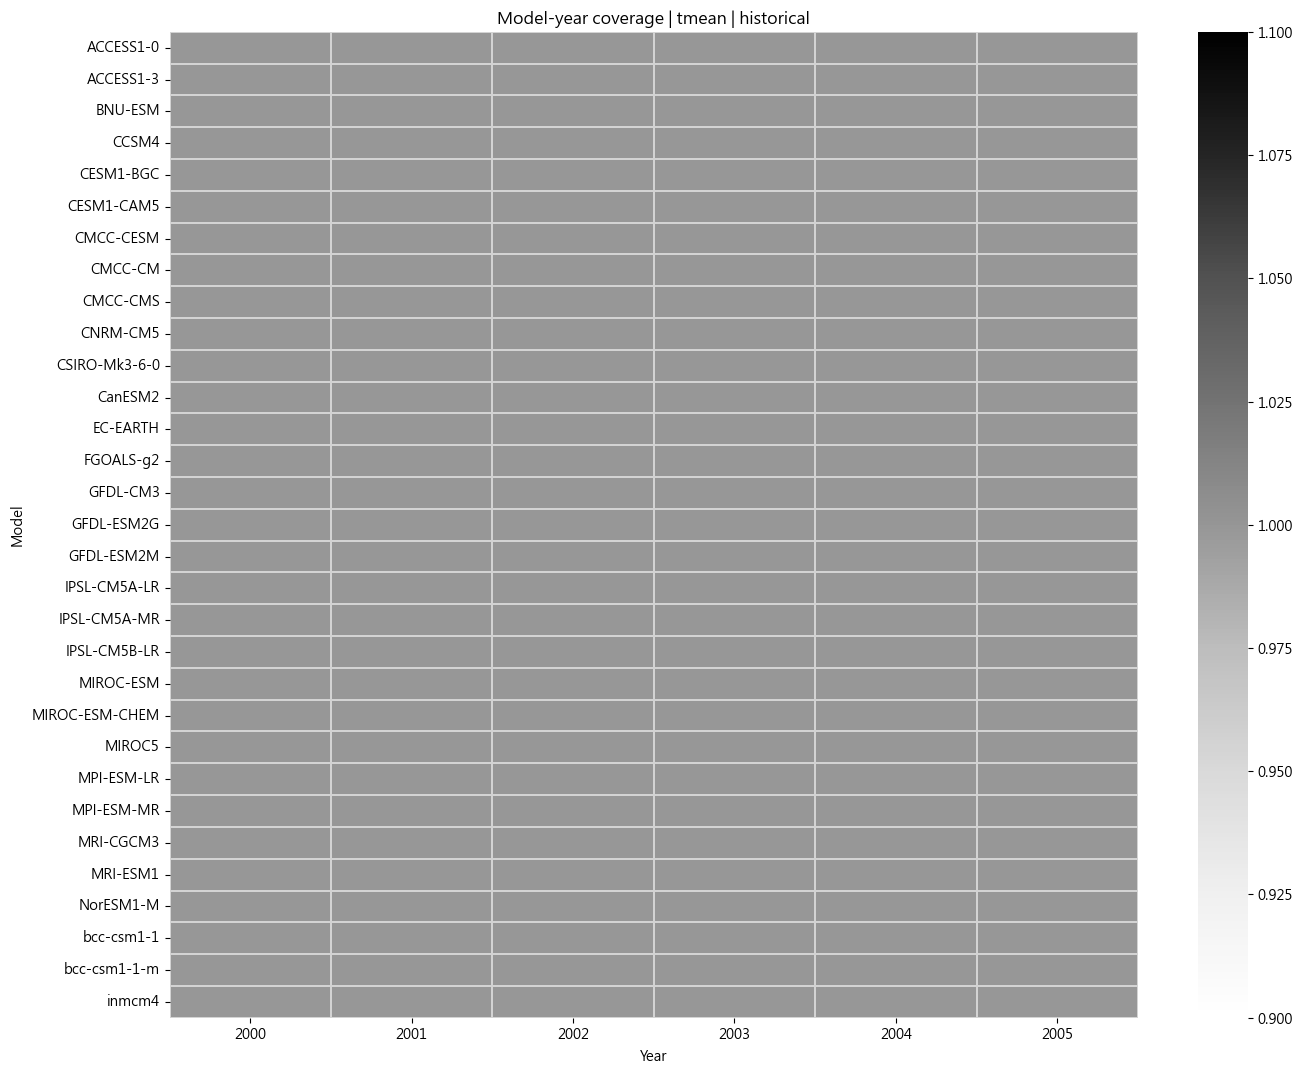

[Saved] C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\missing_heatmaps_allmodels\coverage_heatmap_tmean_rcp26.png


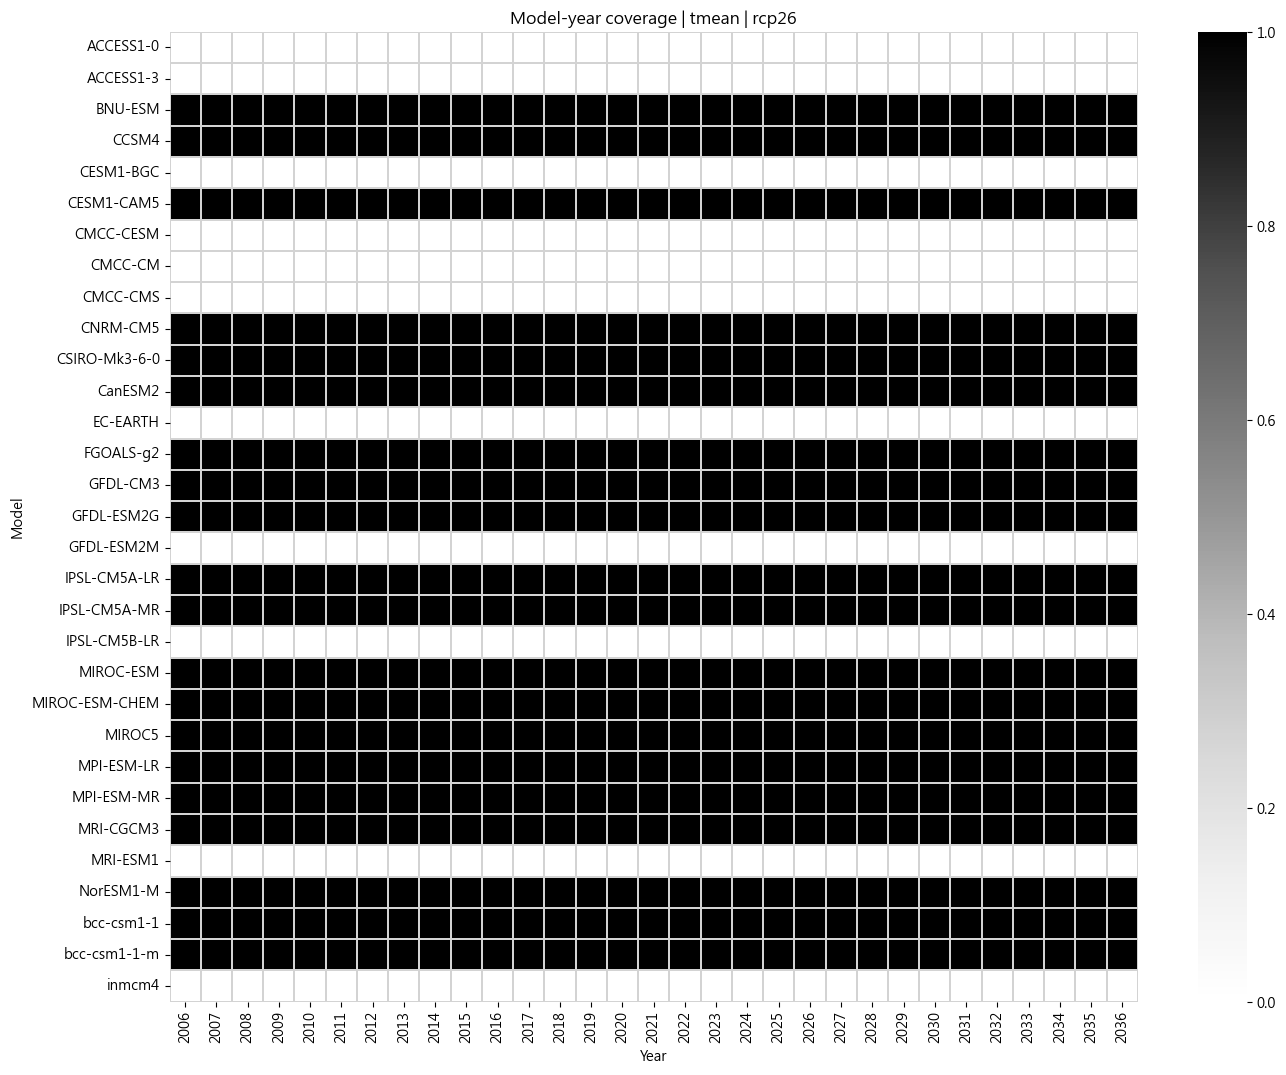

[Saved] C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\missing_heatmaps_allmodels\coverage_heatmap_tmean_rcp45.png


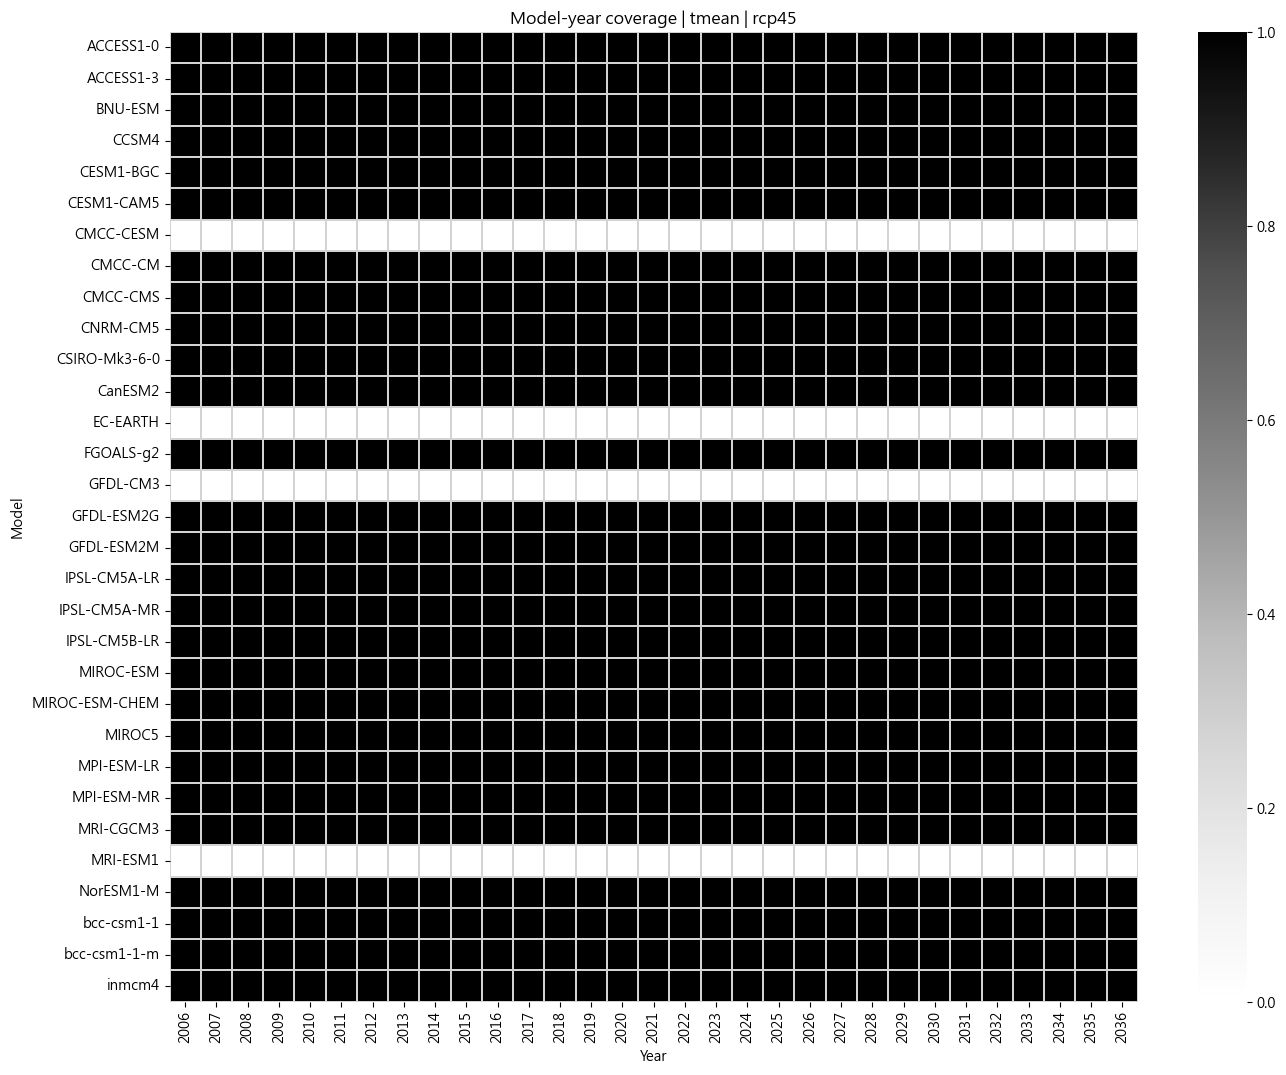

[Saved] C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\missing_heatmaps_allmodels\coverage_heatmap_tmean_rcp60.png


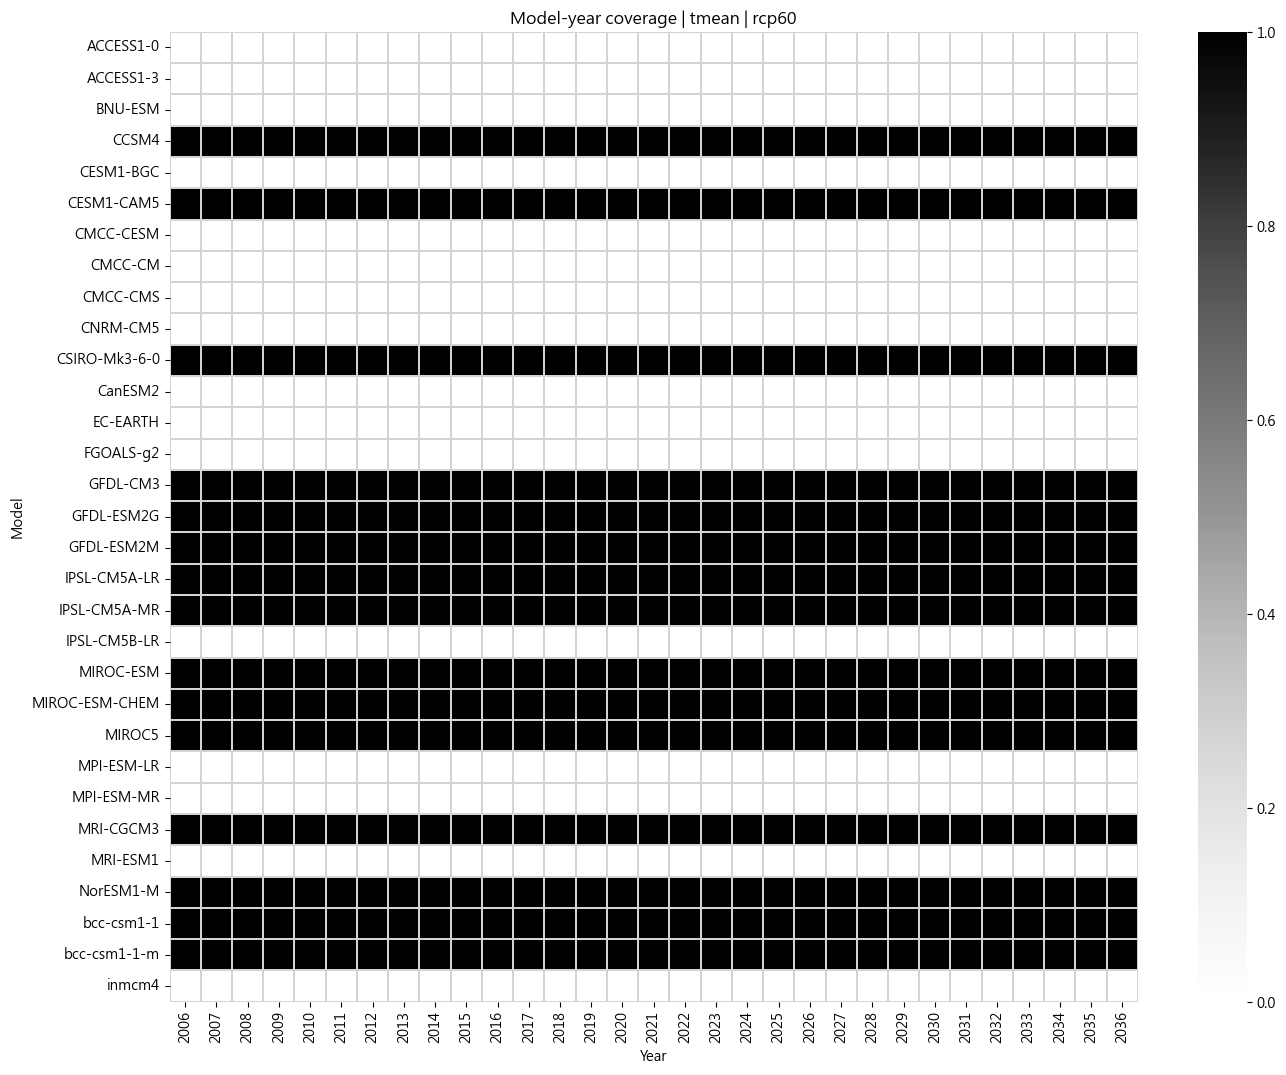

[Saved] C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\missing_heatmaps_allmodels\coverage_heatmap_tmean_rcp85.png


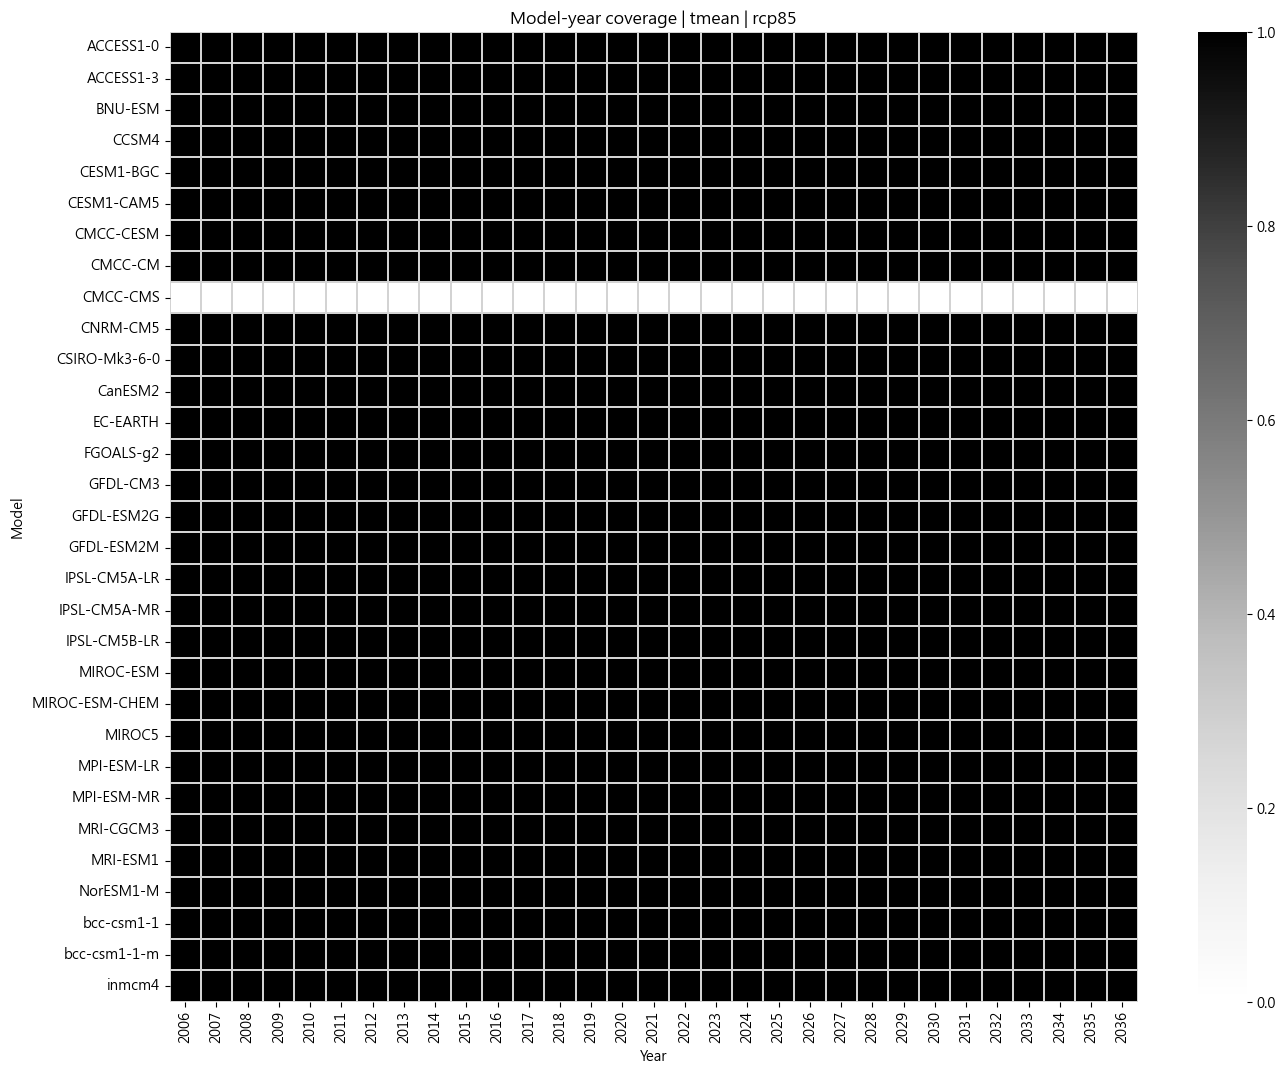

In [35]:
tmean_dir = r"C:\AR5_統計降尺度_日資料_臺北市_平均溫"

plot_all_coverage_heatmaps(
    variable_dir=tmean_dir,
    variable_key="tmean",
    start_year_hist=2000,
    end_year_hist=2005,
    start_year_future=2006,
    end_year_future=2036,
    output_dir=r"C:\Users\user\Climate_project\程式作業\Daxue＿village\figue\missing_heatmaps_allmodels",
    include_historical=True
)

In [ ]:
#MODELS_360_DAY = {"HadGEM2-ES", "HadGEM2-CC", "HadGEM2-AO"}

In [50]:
def plot_ensemble_seasonal_grouped_extra(seasonal_df, interval_name, output_dir):
    """
    額外生成版本：
    每個 interval × 每個 rcp 輸出一張 2x2 四季組圖
    不影響原本主程式。
    """

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    sub_int = seasonal_df[seasonal_df["interval_name"] == interval_name].copy()
    if sub_int.empty:
        print(f"[SKIP] {interval_name}: 無 seasonal 資料")
        return

    variable_key = sub_int["variable"].iloc[0]
    variable_label = VARIABLE_LABEL_MAP.get(variable_key, variable_key)

    plot_title_name = pretty_interval_name(interval_name)
    safe_name = safe_interval_filename(interval_name)

    season_order = ["DJF", "MAM", "JJA", "SON"]

    for rcp in RCPS:
        fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
        axes = axes.flatten()

        plotted_any = False
        legend_handles = None
        legend_labels = None

        for ax, season in zip(axes, season_order):
          #  sub = sub_int[
            #    (sub_int["scenario"].isin(["historical", rcp])) &
              #  (sub_int["season"] == season)
           # ].copy()

            sub = merge_scenario_by_year(sub_int, rcp)

            sub = sub[sub["season"] == season].copy()

            valid_models = filter_complete_models_for_rcp_seasonal(
                seasonal_df=sub,
                rcp=rcp,
                season=season,
                start_year=START_YEAR,
                end_year=END_YEAR
            )

            if not valid_models:
                ax.set_title(f"{season} (no complete models)")
                ax.set_axis_off()
                print(f"[SKIP] {interval_name} | {rcp} | {season}: 無完整模式")
                continue

            sub = sub[sub["model"].isin(valid_models)].copy()

            pivot = (
                sub.pivot_table(
                    index="season_year",
                    columns="model",
                    values="count"
                )
                .sort_index()
            )

            pivot = pivot.loc[(pivot.index >= START_YEAR) & (pivot.index <= END_YEAR)]

            if pivot.empty:
                ax.set_title(f"{season} (no data)")
                ax.set_axis_off()
                print(f"[SKIP] {interval_name} | {rcp} | {season}: 無資料")
                continue

            plotted_any = True
            ensemble_mean = pivot.mean(axis=1)

            for model in pivot.columns:
                ax.plot(
                    pivot.index,
                    pivot[model],
                    color="gray",
                    alpha=0.4,
                    linewidth=1
                )

            mean_line, = ax.plot(
                ensemble_mean.index,
                ensemble_mean.values,
                color="red",
                linewidth=2.3,
                label="Ensemble mean"
            )

            x = ensemble_mean.index.values
            y = ensemble_mean.values

            if len(x) > 1:
                slope, intercept = np.polyfit(x, y, 1)
                trend = slope * x + intercept

                trend_line, = ax.plot(
                    x,
                    trend,
                    color="red",
                    linestyle="--",
                    linewidth=1.8,
                    label=f"Trend ({slope:+.2f} days/yr)"
                )

                ax.text(
                    0.03, 0.95,
                    f"Slope = {slope:+.2f} days/yr\nModels = {len(valid_models)}",
                    transform=ax.transAxes,
                    ha="left",
                    va="top",
                    fontsize=9,
                    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
                )

                if legend_handles is None:
                    legend_handles = [mean_line, trend_line]
                    legend_labels = ["Ensemble mean", f"Trend ({slope:+.2f} days/yr)"]

            ax.set_title(season, fontsize=12)
            ax.grid(alpha=0.25)

        if not plotted_any:
            plt.close(fig)
            print(f"[SKIP] {interval_name} | {rcp}: 四季都無可畫資料")
            continue

        fig.suptitle(
            f"{plot_title_name} | {variable_label} | historical + {rcp}",
            fontsize=14,
            y=0.98
        )
        fig.supxlabel("Year", fontsize=12)
        fig.supylabel("Days", fontsize=12)

        if legend_handles is not None:
            fig.legend(
                legend_handles,
                legend_labels,
                loc="upper center",
                ncol=2,
                bbox_to_anchor=(0.5, 0.93),
                frameon=False
            )

        plt.tight_layout(rect=[0.03, 0.04, 1, 0.90])

        outpath = output_dir / f"{safe_name}_{rcp}_seasonal_2x2_extra.png"
        plt.savefig(outpath, dpi=300, bbox_inches="tight")
        plt.close()

        print(f"[OK] Extra seasonal grouped | {interval_name} | {rcp}")

In [51]:
import re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


def pretty_interval_name(interval_name: str) -> str:
    """
    只處理圖上顯示，不改動原始資料。
    例：
    'Tmin >=15.9°C' -> 'Tmin ≥15.9°C'
    'Tmin 20-25°C'  -> 'Tmin 20–25°C'
    """
    text = str(interval_name)

    text = text.replace(">=", "≥")
    text = text.replace("<=", "≤")

    # 把數字區間中的 - 改成 en dash
    text = re.sub(r"(\d+(?:\.\d+)?)\-(\d+(?:\.\d+)?)", r"\1–\2", text)

    return text


def safe_interval_filename(interval_name: str) -> str:
    """
    轉成可安全存檔的名稱。
    """
    text = str(interval_name)
    text = text.replace(" ", "_")
    text = text.replace("≥", "ge")
    text = text.replace("<=", "le")
    text = text.replace("≤", "le")
    text = text.replace(">=", "ge")
    text = text.replace("–", "_to_")
    text = text.replace("-", "_")
    text = text.replace("°C", "C")
    text = text.replace("°", "")
    text = text.replace(".", "_")
    text = text.replace("/", "_")
    return text

In [72]:
def fill_missing_seasonal_counts(seasonal_df, start_year, end_year):
    """
    補齊 seasonal_counts_all 中缺失的年份（補 0）
    """

    all_years = list(range(start_year, end_year + 1))

    filled_list = []

    group_cols = ["model", "scenario", "season", "interval_name", "variable"]

    for keys, sub in seasonal_df.groupby(group_cols):
        model, scenario, season, interval_name, variable = keys

        existing_years = set(sub["season_year"].unique())

        for year in all_years:
            if year in existing_years:
                filled_list.append(sub[sub["season_year"] == year])
            else:
                filled_list.append(pd.DataFrame([{
                    "model": model,
                    "scenario": scenario,
                    "season": season,
                    "season_year": year,
                    "interval_name": interval_name,
                    "variable": variable,
                    "count": 0
                }]))

    filled_df = pd.concat(filled_list, ignore_index=True)

    return filled_df

def fill_missing_yearly_counts(yearly_df, start_year, end_year):
    """
    補齊 yearly_counts_all 中缺失年份
    """

    all_years = list(range(start_year, end_year + 1))

    filled_list = []

    group_cols = ["model", "scenario", "interval_name", "variable"]

    for keys, sub in yearly_df.groupby(group_cols):
        model, scenario, interval_name, variable = keys

        existing_years = set(sub["year"].unique())

        for year in all_years:
            if year in existing_years:
                filled_list.append(sub[sub["year"] == year])
            else:
                filled_list.append(pd.DataFrame([{
                    "model": model,
                    "scenario": scenario,
                    "year": year,
                    "interval_name": interval_name,
                    "variable": variable,
                    "count": 0
                }]))

    filled_df = pd.concat(filled_list, ignore_index=True)

    return filled_df

#def merge_scenario_by_year(df, rcp, split_year=2005):
    """
    把 historical + rcp 正確拼接（不做平均）
    """

   # df = df.copy()

  #  cond = (
      #  ((df["season_year"] <= split_year) & (df["scenario"] == "historical")) |
      #  ((df["season_year"] > split_year) & (df["scenario"] == rcp))
   # )

    return df[cond]

def merge_scenario_by_year(df, rcp, split_year=2005):
    """
    historical 到 split_year
    split_year+1 之後用指定 rcp
    """
    df = df.copy()

    cond = (
        ((df["season_year"] <= split_year) & (df["scenario"] == "historical")) |
        ((df["season_year"] > split_year) & (df["scenario"] == rcp))
    )

    return df.loc[cond].copy()


def filter_complete_models_for_rcp_seasonal(seasonal_df, rcp, season, start_year=2000, end_year=2036):
    required_years = set(range(start_year, end_year + 1))
    valid_models = []

    if season == "DJF":
        required_years = set(range(start_year + 1, end_year + 1))
    else:
        required_years = set(range(start_year, end_year + 1))
    # 先正確拼接 historical + rcp
    sub = merge_scenario_by_year(seasonal_df, rcp)

    # 再選特定季節
    sub = sub[sub["season"] == season].copy()

    for model, g in sub.groupby("model"):
        years = set(g["season_year"].unique())
        if required_years.issubset(years):
            valid_models.append(model)

    return sorted(valid_models)

In [53]:
yearly_counts_all = pd.read_csv(
    OUTPUT_DIR / f"yearly_counts_all_intervals_{START_YEAR}_{END_YEAR}.csv",
    encoding="utf-8-sig"
)

In [54]:
seasonal_counts_filled = fill_missing_seasonal_counts(
    seasonal_counts_all,
    start_year=START_YEAR,
    end_year=END_YEAR
)

yearly_counts_filled = fill_missing_yearly_counts(
    yearly_counts_all,
    start_year=START_YEAR,
    end_year=END_YEAR
)

In [55]:
generate_extra_seasonal_grouped_plots(seasonal_counts_filled)



=== 開始額外輸出四季組圖 ===
[OK] Extra seasonal grouped | Tmax 26–29°C | rcp26
[OK] Extra seasonal grouped | Tmax 26–29°C | rcp45
[OK] Extra seasonal grouped | Tmax 26–29°C | rcp60
[OK] Extra seasonal grouped | Tmax 26–29°C | rcp85
[SKIP] Tmean 28–31°C | rcp26 | DJF: 無完整模式
[OK] Extra seasonal grouped | Tmean 28–31°C | rcp26
[SKIP] Tmean 28–31°C | rcp45 | DJF: 無完整模式
[OK] Extra seasonal grouped | Tmean 28–31°C | rcp45
[SKIP] Tmean 28–31°C | rcp60 | DJF: 無完整模式
[OK] Extra seasonal grouped | Tmean 28–31°C | rcp60
[SKIP] Tmean 28–31°C | rcp85 | DJF: 無完整模式
[OK] Extra seasonal grouped | Tmean 28–31°C | rcp85
[OK] Extra seasonal grouped | Tmin 20–25°C | rcp26
[OK] Extra seasonal grouped | Tmin 20–25°C | rcp45
[OK] Extra seasonal grouped | Tmin 20–25°C | rcp60
[OK] Extra seasonal grouped | Tmin 20–25°C | rcp85


C:\Users\user\AppData\Local\Temp\ipykernel_21276\2726072318.py:151: UserWarning: Glyph 8805 (\N{GREATER-THAN OR EQUAL TO}) missing from font(s) Microsoft JhengHei.
  plt.tight_layout(rect=[0.03, 0.04, 1, 0.90])
C:\Users\user\AppData\Local\Temp\ipykernel_21276\2726072318.py:154: UserWarning: Glyph 8805 (\N{GREATER-THAN OR EQUAL TO}) missing from font(s) Microsoft JhengHei.
  plt.savefig(outpath, dpi=300, bbox_inches="tight")


[OK] Extra seasonal grouped | Tmin ≥15.9°C | rcp26


C:\Users\user\AppData\Local\Temp\ipykernel_21276\2726072318.py:151: UserWarning: Glyph 8805 (\N{GREATER-THAN OR EQUAL TO}) missing from font(s) Microsoft JhengHei.
  plt.tight_layout(rect=[0.03, 0.04, 1, 0.90])
C:\Users\user\AppData\Local\Temp\ipykernel_21276\2726072318.py:154: UserWarning: Glyph 8805 (\N{GREATER-THAN OR EQUAL TO}) missing from font(s) Microsoft JhengHei.
  plt.savefig(outpath, dpi=300, bbox_inches="tight")


[OK] Extra seasonal grouped | Tmin ≥15.9°C | rcp45


C:\Users\user\AppData\Local\Temp\ipykernel_21276\2726072318.py:151: UserWarning: Glyph 8805 (\N{GREATER-THAN OR EQUAL TO}) missing from font(s) Microsoft JhengHei.
  plt.tight_layout(rect=[0.03, 0.04, 1, 0.90])
C:\Users\user\AppData\Local\Temp\ipykernel_21276\2726072318.py:154: UserWarning: Glyph 8805 (\N{GREATER-THAN OR EQUAL TO}) missing from font(s) Microsoft JhengHei.
  plt.savefig(outpath, dpi=300, bbox_inches="tight")


[OK] Extra seasonal grouped | Tmin ≥15.9°C | rcp60


C:\Users\user\AppData\Local\Temp\ipykernel_21276\2726072318.py:151: UserWarning: Glyph 8805 (\N{GREATER-THAN OR EQUAL TO}) missing from font(s) Microsoft JhengHei.
  plt.tight_layout(rect=[0.03, 0.04, 1, 0.90])
C:\Users\user\AppData\Local\Temp\ipykernel_21276\2726072318.py:154: UserWarning: Glyph 8805 (\N{GREATER-THAN OR EQUAL TO}) missing from font(s) Microsoft JhengHei.
  plt.savefig(outpath, dpi=300, bbox_inches="tight")


[OK] Extra seasonal grouped | Tmin ≥15.9°C | rcp85
=== 額外四季組圖輸出完成 ===


In [57]:
test = seasonal_counts_filled[
    (seasonal_counts_filled["interval_name"] == "Tmean 28–31°C") &
    (seasonal_counts_filled["season"] == "JJA") &
    (seasonal_counts_filled["model"] == seasonal_counts_filled["model"].unique()[0]) &
    (seasonal_counts_filled["season_year"].isin([2004, 2005, 2006, 2007]))
].sort_values(["season_year", "scenario"])

print(test[["season_year", "scenario", "count"]])

      season_year    scenario  count
152          2004  historical     71
707          2004       rcp45      0
1262         2004       rcp85      0
153          2005  historical     62
708          2005       rcp45      0
1263         2005       rcp85      0
154          2006  historical      0
709          2006       rcp45     66
1264         2006       rcp85     58
155          2007  historical      0
710          2007       rcp45     48
1265         2007       rcp85     53


In [3]:
def plot_seasonal_coverage_heatmap_v2(
    seasonal_df,
    interval_name,
    rcp,
    season,
    start_year=2000,
    end_year=2036
):
    """
    用 interval_name 畫 seasonal coverage heatmap
    例如 interval_name = "Tmean 28–31°C"
    """

    sub = merge_scenario_by_year(seasonal_df, rcp)
    sub = sub[
        (sub["interval_name"] == interval_name) &
        (sub["season"] == season)
    ].copy()

    if sub.empty:
        print(f"[SKIP] {interval_name} | {rcp} | {season}: 無資料")
        return

    models = sorted(sub["model"].unique())

    if season == "DJF":
        years = list(range(start_year + 1, end_year + 1))
    else:
        years = list(range(start_year, end_year + 1))

    full_index = pd.MultiIndex.from_product(
        [models, years],
        names=["model", "season_year"]
    )

    sub = sub.set_index(["model", "season_year"]).reindex(full_index)

    sub["has_data"] = sub["count"].notna().astype(int)

    heatmap_df = sub["has_data"].unstack()

    plt.figure(figsize=(12, max(4, len(models) * 0.35)))

    sns.heatmap(
        heatmap_df,
        cmap="Greys",
        cbar=True,
        linewidths=0.3,
        linecolor="lightgray"
    )

    plt.title(f"Seasonal Data Coverage | {interval_name} | {rcp} | {season}")
    plt.xlabel("Year")
    plt.ylabel("Model")
    plt.tight_layout()
    plt.show()

In [66]:
plot_seasonal_coverage_heatmap_v2(
    seasonal_df=seasonal_counts_filled,
    interval_name="Tmean 28–31°C",
    rcp="rcp45",
    season="DJF",
    start_year=START_YEAR,
    end_year=END_YEAR
)

[SKIP] Tmean 28–31°C | rcp45 | DJF: 無資料


In [67]:
tmp = seasonal_counts_filled[
    (seasonal_counts_filled["interval_name"] == "Tmean 28–31°C") &
    (seasonal_counts_filled["season"] == "DJF")
].copy()

print(tmp[["season_year", "scenario", "count"]].head(30))
print(tmp["scenario"].value_counts(dropna=False))
print(tmp["count"].describe())

Empty DataFrame
Columns: [season_year, scenario, count]
Index: []
Series([], Name: count, dtype: int64)
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: count, dtype: float64


In [68]:
tmp2 = merge_scenario_by_year(tmp, "rcp60")
print(tmp2[["season_year", "scenario", "count"]].head(30))
print(tmp2.shape)

Empty DataFrame
Columns: [season_year, scenario, count]
Index: []
(0, 7)


In [69]:
check = seasonal_counts_filled[
    seasonal_counts_filled["interval_name"] == "Tmean 28–31°C"
].groupby(["season", "scenario"])["count"].sum()

print(check)

season  scenario  
JJA     historical    12505
        rcp26         38018
        rcp45         52664
        rcp60         29826
        rcp85         58050
MAM     historical      885
        rcp26          5461
        rcp45          6499
        rcp60          3091
        rcp85          6473
SON     historical     3577
        rcp26         14982
        rcp45         19300
        rcp60         10102
        rcp85         19533
Name: count, dtype: int64
